**Step 1 — Import Libraries + Load Sarcasm Dataset**

In [1]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Upload sarcasm dataset

from google.colab import files

uploaded = files.upload()

Saving Sarcasm Model.csv to Sarcasm Model.csv


In [3]:
# Load the uploaded CSV file

import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("File name:", file_name)

Dataset loaded successfully!
File name: Sarcasm Model.csv


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (5666, 3)


**Step 2 — View the dataset.**

In [5]:
# Step 2: View the dataset

print("First 5 rows:")
display(df.head())

First 5 rows:


,id,Label,clean_tweet_v2
0,1,-1,मध्ये करत खरंच करत हेच कळत राव
1,2,-1,अबे येड्या कळतो तुला
2,3,-1,बरं झालं लिहिले आजच बावनकुळे असते तुमचे
3,4,-1,किव्वा चे द्यावे नमो च्या नावाने आहेच विमानतळ ...
4,5,-1,वी नापास नांगरगठ्ठ्या देशाचा पंतप्रधान होऊन बस...


In [6]:
print("\nLast 5 rows:")
display(df.tail())


Last 5 rows:


,id,Label,clean_tweet_v2
5661,5662,1,"""आजच्या बैठकीत सर्वांनी एकत्र येऊन कामाची योग्..."
5662,5663,1,"""घरांमध्ये आज संपूर्ण दिवस खूपच आनंदी आणि उत्स..."
5663,5664,1,"""वाचनालयातील सर्व वाचकांनी शांततेचे नियम तंतोत..."
5664,5665,1,"""आज संध्याकाळी हलके संगीत ऐकत मन शांत केले."""
5665,5666,1,"""शिक्षकांनी सर्व विद्यार्थ्यांना आगामी परीक्षा..."


**Step 3 — Check column names.**

In [7]:
# Step 3: Check column names

print("Column names:")
print(df.columns.tolist())

Column names:
['id', 'Label', 'clean_tweet_v2']


In [8]:
# Step 4: Check data types

print(df.dtypes)

id                 int64
Label              int64
clean_tweet_v2    object
dtype: object


In [9]:
# Step 5: Check missing values

print(df.isnull().sum())

print("\nTotal missing values:",
      df.isnull().sum().sum())

id                0
Label             0
clean_tweet_v2    1
dtype: int64

Total missing values: 1


In [10]:
# Step 6: Inspect the row with missing text

missing_text_rows = df[df['clean_tweet_v2'].isnull()]

display(missing_text_rows)

,id,Label,clean_tweet_v2
207,208,-1,NaN


In [11]:
# Step 6: Remove rows with missing text

df = df.dropna(subset=['clean_tweet_v2']).copy()

print("Missing text rows removed.")
print("New dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Missing text rows removed.
New dataset shape: (5665, 3)

Missing values:
id                0
Label             0
clean_tweet_v2    0
dtype: int64


In [12]:
# Step 7: Check duplicate rows

duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

duplicate_percentage = (duplicate_rows / len(df)) * 100
print("Duplicate percentage:", duplicate_percentage, "%")

Duplicate rows: 0
Duplicate percentage: 0.0 %


In [13]:
# Step 8: Check duplicate text

duplicate_text = df['clean_tweet_v2'].duplicated().sum()

print("Duplicate text entries:", duplicate_text)

Duplicate text entries: 0


In [14]:
if duplicate_text > 0:
    print("\nDuplicate texts found:")
    display(
        df[df['clean_tweet_v2'].duplicated(keep=False)]
        .sort_values('clean_tweet_v2')
    )
else:
    print("No duplicate texts found.")

No duplicate texts found.


In [15]:
# Step 9: Check duplicate text + label combinations

duplicate_text_label = df.duplicated(
    subset=['clean_tweet_v2', 'Label']
).sum()

print("Duplicate text + label combinations:",
      duplicate_text_label)

if duplicate_text_label > 0:
    print("\nDuplicate combinations found:")
    display(
        df[
            df.duplicated(
                subset=['clean_tweet_v2', 'Label'],
                keep=False
            )
        ].sort_values(['clean_tweet_v2', 'Label'])
    )
else:
    print("No duplicate text + label combinations found.")

Duplicate text + label combinations: 0
No duplicate text + label combinations found.


In [16]:
# Step 10: Check sarcasm label distribution

label_counts = df['Label'].value_counts().sort_index()

print("Sarcasm label distribution:")
print(label_counts)

print("\nLabel percentages:")
label_percentages = df['Label'].value_counts(normalize=True).sort_index() * 100
print(label_percentages.round(2))

Sarcasm label distribution:
Label
-1    3221
 1    2444
Name: count, dtype: int64

Label percentages:
Label
-1    56.86
 1    43.14
Name: proportion, dtype: float64


In [17]:
print("\nUnique labels:")
print(sorted(df['Label'].unique()))


Unique labels:
[np.int64(-1), np.int64(1)]


In [18]:
# Step 11: Validate sarcasm labels

expected_labels = {-1, 1}
actual_labels = set(df['Label'].unique())

print("Expected labels:", expected_labels)
print("Actual labels:", actual_labels)

if actual_labels == expected_labels:
    print("\nAll sarcasm labels are valid!")
else:
    print("\nUnexpected labels found:")
    print(actual_labels - expected_labels)

Expected labels: {1, -1}
Actual labels: {np.int64(1), np.int64(-1)}

All sarcasm labels are valid!


In [19]:
# Step 12: Check empty or whitespace-only text

empty_text = (
    df['clean_tweet_v2']
    .astype(str)
    .str.strip()
    .eq('')
    .sum()
)

print("Empty or whitespace-only text:", empty_text)

Empty or whitespace-only text: 0


In [20]:
empty_label = (
    df['Label']
    .astype(str)
    .str.strip()
    .eq('')
    .sum()
)

print("Empty labels:", empty_label)

Empty labels: 0


In [21]:
# Step 13: Clean extra spaces in sarcasm text

df['clean_tweet_v2'] = df['clean_tweet_v2'].str.strip()
df['clean_tweet_v2'] = df['clean_tweet_v2'].str.replace(r'\s+', ' ', regex=True)

print("Sarcasm text cleaned successfully!")
print(df.head())

Sarcasm text cleaned successfully!
   id  Label                                     clean_tweet_v2
0   1     -1                     मध्ये करत खरंच करत हेच कळत राव
1   2     -1                               अबे येड्या कळतो तुला
2   3     -1            बरं झालं लिहिले आजच बावनकुळे असते तुमचे
3   4     -1  किव्वा चे द्यावे नमो च्या नावाने आहेच विमानतळ ...
4   5     -1  वी नापास नांगरगठ्ठ्या देशाचा पंतप्रधान होऊन बस...


In [22]:
# Step 14: Check duplicate text after cleaning

duplicate_text_after_cleaning = df['clean_tweet_v2'].duplicated().sum()

print("Duplicate text after cleaning:", duplicate_text_after_cleaning)

if duplicate_text_after_cleaning > 0:
    print("\nDuplicate texts found:")
    display(
        df[df['clean_tweet_v2'].duplicated(keep=False)]
        .sort_values('clean_tweet_v2')
    )
else:
    print("No duplicate texts found after cleaning.")

Duplicate text after cleaning: 0
No duplicate texts found after cleaning.


In [23]:
# Step 15: Check text length and word count

df['text_length'] = df['clean_tweet_v2'].str.len()
df['word_count'] = df['clean_tweet_v2'].str.split().str.len()

print("Text length statistics:")
print(df['text_length'].describe())

print("\nWord count statistics:")
print(df['word_count'].describe())

Text length statistics:
count    5665.000000
mean       61.944395
std        45.717393
min         2.000000
25%        32.000000
50%        49.000000
75%        76.000000
max       265.000000
Name: text_length, dtype: float64

Word count statistics:
count    5665.000000
mean        9.768049
std         6.962790
min         1.000000
25%         5.000000
50%         7.000000
75%        12.000000
max        43.000000
Name: word_count, dtype: float64


In [24]:
print("\nShortest texts:")
display(
    df[['clean_tweet_v2', 'Label', 'text_length', 'word_count']]
    .sort_values('word_count')
    .head(10)
)


Shortest texts:


,clean_tweet_v2,Label,text_length,word_count
57,विषय,-1,4,1
758,जमलं,-1,4,1
720,तेजोमहालय,-1,9,1
862,पेलुआसन,-1,7,1
831,राव,-1,3,1
990,लवणासुर,-1,7,1
958,मित्रच,-1,6,1
1198,राऊत,-1,4,1
1141,शेंगोळ्या,-1,9,1
1253,विचित्र,-1,7,1


In [25]:
print("\nLongest texts:")
display(
    df[['clean_tweet_v2', 'Label', 'text_length', 'word_count']]
    .sort_values('word_count', ascending=False)
    .head(10)
)


Longest texts:


,clean_tweet_v2,Label,text_length,word_count
2968,तन्ना नि नारे तानी नाना रो ताने नाने ना तन्ना ...,-1,197,43
3298,१ लोककल्याणकारी कामे करता करता स्वतः १० पिढीच ...,-1,246,41
2479,जर व्यंग कळत नसेल गप्प बसणं उचित मित्रा अवघड ठ...,-1,232,41
3249,फार सौम्य भाषेत सांगतो भाषा व्यवस्थित वापर तुझ...,-1,241,39
2960,राज ठाकरेंच्या भोंग्याने जर मविआला घंटा फरक पड...,-1,214,38
1668,मला वाटतंय मंत्रालयात चहाचा घोटाळा झालाच नसेल ...,-1,207,38
2895,व्यंग देशद्रोही वर थंड घेयून च वेळ ना तर्क वित...,-1,162,38
2813,तुम्ही एकदा कंपनी सोडून गेलात कंपनी मॅनेजमेंटब...,-1,235,37
3243,बाळा साहेब व्यंग चित्रकार वकृत्व कला अतित्तम श...,-1,242,37
2748,मित्र नक्की मागिल अडीच वर्ष मुका झालेला बहुतेक...,-1,227,37


In [26]:
# Step 16: Keep all columns for future use

print("Current columns:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

Current columns:
['id', 'Label', 'clean_tweet_v2', 'text_length', 'word_count']

Dataset shape:
(5665, 5)


In [27]:
# Step 17: Final preprocessing validation

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDuplicate texts:", df['clean_tweet_v2'].duplicated().sum())

print("\nSarcasm label distribution:")
print(df['Label'].value_counts().sort_index())

print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (5665, 5)

Missing values:
id                0
Label             0
clean_tweet_v2    0
text_length       0
word_count        0
dtype: int64

Duplicate rows: 0

Duplicate texts: 0

Sarcasm label distribution:
Label
-1    3221
 1    2444
Name: count, dtype: int64

Columns:
['id', 'Label', 'clean_tweet_v2', 'text_length', 'word_count']


In [28]:
# Step 18: Create features (X) and target (y)

X = df['clean_tweet_v2']
y = df['Label']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 X values:")
print(X.head())

print("\nFirst 5 y values:")
print(y.head())

X shape: (5665,)
y shape: (5665,)

First 5 X values:
0                       मध्ये करत खरंच करत हेच कळत राव
1                                 अबे येड्या कळतो तुला
2              बरं झालं लिहिले आजच बावनकुळे असते तुमचे
3    किव्वा चे द्यावे नमो च्या नावाने आहेच विमानतळ ...
4    वी नापास नांगरगठ्ठ्या देशाचा पंतप्रधान होऊन बस...
Name: clean_tweet_v2, dtype: object

First 5 y values:
0   -1
1   -1
2   -1
3   -1
4   -1
Name: Label, dtype: int64


In [29]:
# Step 19: Encode sarcasm labels

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Label mapping:")

for label, encoded_value in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(label, "→", encoded_value)

print("\nFirst 10 encoded labels:")
print(y_encoded[:10])

Label mapping:
-1 → 0
1 → 1

First 10 encoded labels:
[0 0 0 0 0 0 0 1 0 0]


In [30]:
# Step 20: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4532
Testing samples: 1133


In [31]:
print("\nTraining label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting label distribution:")
print(pd.Series(y_test).value_counts().sort_index())


Training label distribution:
0    2577
1    1955
Name: count, dtype: int64

Testing label distribution:
0    644
1    489
Name: count, dtype: int64


In [32]:
# Step 21: Marathi-aware TF-IDF

import re
from sklearn.feature_extraction.text import TfidfVectorizer

def marathi_tokenizer(text):
    return re.findall(r'[\u0900-\u097F]+', text)

tfidf_vectorizer = TfidfVectorizer(
    tokenizer=marathi_tokenizer,
    token_pattern=None,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4532, 7147)
Testing TF-IDF shape: (1133, 7147)


In [33]:
# Step 22: Inspect TF-IDF vocabulary

feature_names = tfidf_vectorizer.get_feature_names_out()

print("Total TF-IDF features:", len(feature_names))

print("\nFirst 30 features:")
print(feature_names[:30])

Total TF-IDF features: 7147

First 30 features:
['अ' 'अँबॅसेडरची' 'अंकल' 'अंगण' 'अंगणात' 'अंगणात सुंदर' 'अंगावर' 'अंघोळ'
 'अंडी' 'अंडे' 'अंत' 'अंतिम' 'अंदाज' 'अंध' 'अंबानी' 'अंबानीच्या' 'अकाउंट'
 'अकाऊंट' 'अक्कल' 'अक्कल योग्य' 'अक्कल शून्य' 'अक्षय' 'अक्षरात'
 'अक्षरात पूर्ण' 'अखंड' 'अखंडित' 'अखंडित होता' 'अखिल' 'अखिल भारतीय'
 'अख्खा']


In [34]:
# Check non-zero TF-IDF features

first_vector = X_train_tfidf[0]

print("\nNumber of non-zero features in first sentence:",
      first_vector.nnz)

print("TF-IDF vector shape:",
      first_vector.shape)


Number of non-zero features in first sentence: 9
TF-IDF vector shape: (1, 7147)


In [35]:
# Step 23: Train Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [36]:
# Step 24: Logistic Regression predictions

y_pred_logistic = logistic_model.predict(X_test_tfidf)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_logistic))

print("\nFirst 10 predictions:")
print(y_pred_logistic[:10])


Predictions generated successfully!
Number of predictions: 1133

First 10 predictions:
[1 0 0 1 1 0 1 0 1 0]


In [37]:
# Step 25: Evaluate Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    average='weighted'
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    average='weighted'
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    average='weighted'
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1-score :", round(f1_logistic, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Logistic Regression Results
---------------------------
Accuracy : 0.8835
Precision: 0.8936
Recall   : 0.8835
F1-score : 0.8811

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.84      0.98      0.90       644
    Sarcastic       0.96      0.76      0.85       489

     accuracy                           0.88      1133
    macro avg       0.90      0.87      0.88      1133
 weighted avg       0.89      0.88      0.88      1133


Confusion Matrix:
[[628  16]
 [116 373]]


In [38]:
# Step 26: Store Logistic Regression results

results = []

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_logistic,
    'Precision': precision_logistic,
    'Recall': recall_logistic,
    'F1-Score': f1_logistic
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.883495,0.893626,0.883495,0.881057


In [39]:
# Step 27: Train Multinomial Naive Bayes

from sklearn.naive_bayes import MultinomialNB

naive_bayes_model = MultinomialNB()

naive_bayes_model.fit(X_train_tfidf, y_train)

print("Multinomial Naive Bayes model trained successfully!")

Multinomial Naive Bayes model trained successfully!


In [40]:
# Step 27: Train Multinomial Naive Bayes

from sklearn.naive_bayes import MultinomialNB

naive_bayes_model = MultinomialNB()

naive_bayes_model.fit(X_train_tfidf, y_train)

print("Multinomial Naive Bayes model trained successfully!")

Multinomial Naive Bayes model trained successfully!


In [41]:
# Step 28: Make Naive Bayes predictions

y_pred_nb = naive_bayes_model.predict(X_test_tfidf)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_nb))

print("\nFirst 10 predictions:")
print(y_pred_nb[:10])

Predictions generated successfully!
Number of predictions: 1133

First 10 predictions:
[1 0 0 1 1 0 1 0 1 0]


In [42]:
# Step 29: Evaluate Multinomial Naive Bayes

accuracy_nb = accuracy_score(y_test, y_pred_nb)

precision_nb = precision_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

recall_nb = recall_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

print("Multinomial Naive Bayes Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1-score :", round(f1_nb, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Multinomial Naive Bayes Results
--------------------------------
Accuracy : 0.865
Precision: 0.8746
Recall   : 0.865
F1-score : 0.862

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.83      0.96      0.89       644
    Sarcastic       0.94      0.74      0.83       489

     accuracy                           0.86      1133
    macro avg       0.88      0.85      0.86      1133
 weighted avg       0.87      0.86      0.86      1133


Confusion Matrix:
[[619  25]
 [128 361]]


In [43]:
# Step 30: Store Naive Bayes results

results.append({
    'Model': 'Multinomial Naive Bayes',
    'Accuracy': accuracy_nb,
    'Precision': precision_nb,
    'Recall': recall_nb,
    'F1-Score': f1_nb
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.883495,0.893626,0.883495,0.881057
1,Multinomial Naive Bayes,0.864960,0.874650,0.864960,0.862012


In [44]:
# Step 31: Train SVM

from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42,
    max_iter=2000
)

svm_model.fit(X_train_tfidf, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [45]:
# Step 32: SVM predictions

y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM predictions generated successfully!")
print("Number of predictions:", len(y_pred_svm))

print("\nFirst 10 predictions:")
print(y_pred_svm[:10])

SVM predictions generated successfully!
Number of predictions: 1133

First 10 predictions:
[1 0 0 1 1 0 1 0 1 0]


In [46]:
# Step 33: Evaluate SVM

accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

print("SVM Results")
print("-----------")
print("Accuracy :", round(accuracy_svm, 4))
print("Precision:", round(precision_svm, 4))
print("Recall   :", round(recall_svm, 4))
print("F1-score :", round(f1_svm, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Results
-----------
Accuracy : 0.8658
Precision: 0.8662
Recall   : 0.8658
F1-score : 0.8651

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.86      0.91      0.89       644
    Sarcastic       0.87      0.81      0.84       489

     accuracy                           0.87      1133
    macro avg       0.87      0.86      0.86      1133
 weighted avg       0.87      0.87      0.87      1133


Confusion Matrix:
[[586  58]
 [ 94 395]]


In [47]:
# Step 33: Evaluate SVM

accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

print("SVM Results")
print("-----------")
print("Accuracy :", round(accuracy_svm, 4))
print("Precision:", round(precision_svm, 4))
print("Recall   :", round(recall_svm, 4))
print("F1-score :", round(f1_svm, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Results
-----------
Accuracy : 0.8658
Precision: 0.8662
Recall   : 0.8658
F1-score : 0.8651

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.86      0.91      0.89       644
    Sarcastic       0.87      0.81      0.84       489

     accuracy                           0.87      1133
    macro avg       0.87      0.86      0.86      1133
 weighted avg       0.87      0.87      0.87      1133


Confusion Matrix:
[[586  58]
 [ 94 395]]


In [48]:
# Step 34: Store SVM results

results.append({
    'Model': 'SVM',
    'Accuracy': accuracy_svm,
    'Precision': precision_svm,
    'Recall': recall_svm,
    'F1-Score': f1_svm
})

results_df = pd.DataFrame(results)

display(results_df)


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.883495,0.893626,0.883495,0.881057
1,Multinomial Naive Bayes,0.864960,0.874650,0.864960,0.862012
2,SVM,0.865843,0.866167,0.865843,0.865103


In [49]:
# Step 35: Train Random Forest

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_tfidf, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [50]:
# Step 36: Random Forest predictions

y_pred_rf = random_forest_model.predict(X_test_tfidf)

print("Random Forest predictions generated successfully!")
print("Number of predictions:", len(y_pred_rf))

print("\nFirst 10 predictions:")
print(y_pred_rf[:10])

Random Forest predictions generated successfully!
Number of predictions: 1133

First 10 predictions:
[1 0 0 1 1 0 1 0 1 0]


In [51]:
# Step 37: Evaluate Random Forest

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1-score :", round(f1_rf, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy : 0.8817
Precision: 0.8879
Recall   : 0.8817
F1-score : 0.8799

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.85      0.96      0.90       644
    Sarcastic       0.94      0.78      0.85       489

     accuracy                           0.88      1133
    macro avg       0.89      0.87      0.88      1133
 weighted avg       0.89      0.88      0.88      1133


Confusion Matrix:
[[618  26]
 [108 381]]


In [52]:
# Step 38: Store Random Forest results

results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.883495,0.893626,0.883495,0.881057
1,Multinomial Naive Bayes,0.864960,0.874650,0.864960,0.862012
2,SVM,0.865843,0.866167,0.865843,0.865103
3,Random Forest,0.881730,0.887873,0.881730,0.879857


In [53]:
# Step 39: Train Decision Tree

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train_tfidf, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [54]:
# Step 40: Decision Tree predictions

y_pred_dt = decision_tree_model.predict(X_test_tfidf)

print("Decision Tree predictions generated successfully!")
print("Number of predictions:", len(y_pred_dt))

print("\nFirst 10 predictions:")
print(y_pred_dt[:10])

Decision Tree predictions generated successfully!
Number of predictions: 1133

First 10 predictions:
[1 1 0 1 1 0 1 0 1 0]


In [55]:
# Step 41: Evaluate Decision Tree

accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1-score :", round(f1_dt, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Results
---------------------
Accuracy : 0.8553
Precision: 0.855
Recall   : 0.8553
F1-score : 0.8549

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.86      0.89      0.87       644
    Sarcastic       0.84      0.82      0.83       489

     accuracy                           0.86      1133
    macro avg       0.85      0.85      0.85      1133
 weighted avg       0.85      0.86      0.85      1133


Confusion Matrix:
[[570  74]
 [ 90 399]]


In [56]:
# Step 42: Store Decision Tree results

results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_dt,
    'Precision': precision_dt,
    'Recall': recall_dt,
    'F1-Score': f1_dt
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.883495,0.893626,0.883495,0.881057
1,Multinomial Naive Bayes,0.864960,0.874650,0.864960,0.862012
2,SVM,0.865843,0.866167,0.865843,0.865103
3,Random Forest,0.881730,0.887873,0.881730,0.879857
4,Decision Tree,0.855252,0.854968,0.855252,0.854936


In [57]:
# Step 43: Final sarcasm model comparison

results_df = results_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

display(results_df)

best_model_name = results_df.loc[0, 'Model']
best_accuracy = results_df.loc[0, 'Accuracy']
best_f1 = results_df.loc[0, 'F1-Score']

print("\nBest Sarcasm Model:", best_model_name)
print("Best Accuracy:", round(best_accuracy, 4))
print("Best F1-Score:", round(best_f1, 4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.883495,0.893626,0.883495,0.881057
1,Random Forest,0.881730,0.887873,0.881730,0.879857
2,SVM,0.865843,0.866167,0.865843,0.865103
3,Multinomial Naive Bayes,0.864960,0.874650,0.864960,0.862012
4,Decision Tree,0.855252,0.854968,0.855252,0.854936



Best Sarcasm Model: Logistic Regression
Best Accuracy: 0.8835
Best F1-Score: 0.8811


In [58]:
# Step 44: Test the best sarcasm model on new Marathi sentences

best_sarcasm_model = logistic_model

new_sentences = [
    "वा! खूपच छान सेवा आहे, तीन तास वाट पाहायला लावली.",
    "आजचा कार्यक्रम खूप सुंदर आणि आनंददायी होता.",
    "काय अप्रतिम काम केलंस, सगळं बिघडवलंस.",
    "उद्या कॉलेजमध्ये परीक्षा होणार आहे.",
    "वा, किती सुंदर हवामान आहे, बाहेर पाऊसच पाऊस आहे."
]

# Convert new text using the SAME TF-IDF vectorizer
new_sentences_tfidf = tfidf_vectorizer.transform(new_sentences)

# Predict
new_predictions = best_sarcasm_model.predict(new_sentences_tfidf)

# Convert 0/1 back to original -1/1 labels
new_labels = label_encoder.inverse_transform(new_predictions)

print("New Sentence Predictions:\n")

for text, prediction in zip(new_sentences, new_labels):
    print("Text:", text)
    print("Prediction:", prediction)
    print("-" * 60)

New Sentence Predictions:

Text: वा! खूपच छान सेवा आहे, तीन तास वाट पाहायला लावली.
Prediction: 1
------------------------------------------------------------
Text: आजचा कार्यक्रम खूप सुंदर आणि आनंददायी होता.
Prediction: 1
------------------------------------------------------------
Text: काय अप्रतिम काम केलंस, सगळं बिघडवलंस.
Prediction: -1
------------------------------------------------------------
Text: उद्या कॉलेजमध्ये परीक्षा होणार आहे.
Prediction: 1
------------------------------------------------------------
Text: वा, किती सुंदर हवामान आहे, बाहेर पाऊसच पाऊस आहे.
Prediction: 1
------------------------------------------------------------


In [59]:
# Step 45: Final validation of the best sarcasm model

best_sarcasm_model = logistic_model

y_pred_best_sarcasm = best_sarcasm_model.predict(X_test_tfidf)

final_accuracy_sarcasm = accuracy_score(
    y_test,
    y_pred_best_sarcasm
)

final_precision_sarcasm = precision_score(
    y_test,
    y_pred_best_sarcasm,
    average='weighted'
)

final_recall_sarcasm = recall_score(
    y_test,
    y_pred_best_sarcasm,
    average='weighted'
)

final_f1_sarcasm = f1_score(
    y_test,
    y_pred_best_sarcasm,
    average='weighted'
)

print("FINAL BEST MODEL: LOGISTIC REGRESSION")
print("--------------------------------------")
print("Accuracy :", round(final_accuracy_sarcasm, 4))
print("Precision:", round(final_precision_sarcasm, 4))
print("Recall   :", round(final_recall_sarcasm, 4))
print("F1-score :", round(final_f1_sarcasm, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_best_sarcasm,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_best_sarcasm
    )
)

FINAL BEST MODEL: LOGISTIC REGRESSION
--------------------------------------
Accuracy : 0.8835
Precision: 0.8936
Recall   : 0.8835
F1-score : 0.8811

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.84      0.98      0.90       644
    Sarcastic       0.96      0.76      0.85       489

     accuracy                           0.88      1133
    macro avg       0.90      0.87      0.88      1133
 weighted avg       0.89      0.88      0.88      1133


Confusion Matrix:
[[628  16]
 [116 373]]


In [60]:
# Step 46: Save the best sarcasm model and preprocessing components

import joblib

# Save best sarcasm model
joblib.dump(
    best_sarcasm_model,
    'sarcasm_logistic_regression.pkl'
)

# Save TF-IDF vectorizer
joblib.dump(
    tfidf_vectorizer,
    'sarcasm_tfidf_vectorizer.pkl'
)

# Save label encoder
joblib.dump(
    label_encoder,
    'sarcasm_label_encoder.pkl'
)

print("All sarcasm ML components saved successfully!")

All sarcasm ML components saved successfully!


In [61]:
import os

files_to_check = [
    'sarcasm_logistic_regression.pkl',
    'sarcasm_tfidf_vectorizer.pkl',
    'sarcasm_label_encoder.pkl'
]

print("Saved files:")

for file in files_to_check:
    print(file, "→", os.path.getsize(file), "bytes")

Saved files:
sarcasm_logistic_regression.pkl → 58047 bytes
sarcasm_tfidf_vectorizer.pkl → 260546 bytes
sarcasm_label_encoder.pkl → 343 bytes


In [62]:
# Save final cleaned sarcasm dataset

final_sarcasm_dataset = df.copy()

final_sarcasm_dataset.to_csv(
    'final_sarcasm_dataset.csv',
    index=False,
    encoding='utf-8-sig'
)

print("Final sarcasm dataset saved successfully!")
print("Shape:", final_sarcasm_dataset.shape)
print("Columns:", final_sarcasm_dataset.columns.tolist())

Final sarcasm dataset saved successfully!
Shape: (5665, 5)
Columns: ['id', 'Label', 'clean_tweet_v2', 'text_length', 'word_count']


In [63]:
from google.colab import files

files.download('sarcasm_logistic_regression.pkl')
files.download('sarcasm_tfidf_vectorizer.pkl')
files.download('sarcasm_label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
# Save final sarcasm dataset

final_sarcasm_dataset = df.copy()

final_sarcasm_dataset.to_csv(
    'final_sarcasm_dataset.csv',
    index=False,
    encoding='utf-8-sig'
)

print("Final sarcasm dataset saved successfully!")
print("Shape:", final_sarcasm_dataset.shape)
print("Columns:", final_sarcasm_dataset.columns.tolist())

Final sarcasm dataset saved successfully!
Shape: (5665, 5)
Columns: ['id', 'Label', 'clean_tweet_v2', 'text_length', 'word_count']


In [65]:
from google.colab import files

files.download('final_sarcasm_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.883495,0.893626,0.883495,0.881057
1,Random Forest,0.881730,0.887873,0.881730,0.879857
2,SVM,0.865843,0.866167,0.865843,0.865103
3,Multinomial Naive Bayes,0.864960,0.874650,0.864960,0.862012
4,Decision Tree,0.855252,0.854968,0.855252,0.854936


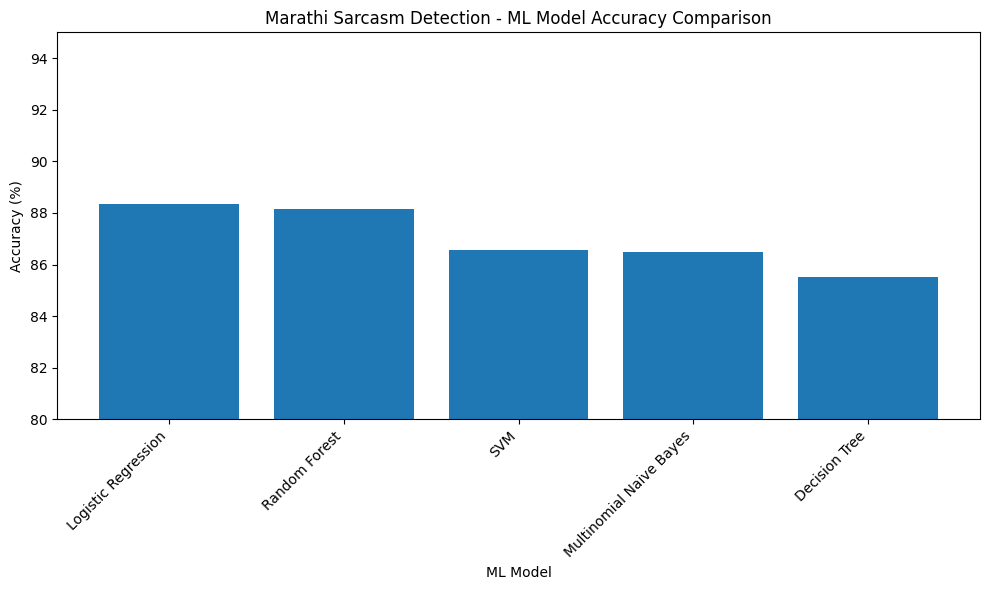

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by F1-score
results_df = results_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

display(results_df)

plt.figure(figsize=(10, 6))

plt.bar(
    results_df['Model'],
    results_df['Accuracy'] * 100
)

plt.xlabel('ML Model')
plt.ylabel('Accuracy (%)')
plt.title('Marathi Sarcasm Detection - ML Model Accuracy Comparison')

plt.xticks(rotation=45, ha='right')
plt.ylim(80, 95)

plt.tight_layout()

plt.savefig(
    'sarcasm_ml_accuracy_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

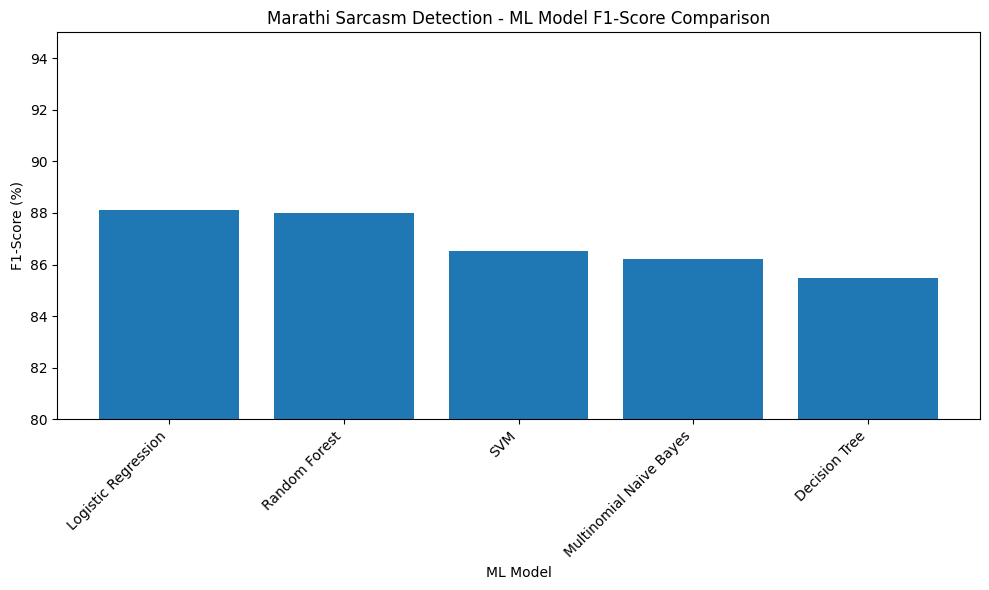

In [67]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df['Model'],
    results_df['F1-Score'] * 100
)

plt.xlabel('ML Model')
plt.ylabel('F1-Score (%)')
plt.title('Marathi Sarcasm Detection - ML Model F1-Score Comparison')

plt.xticks(rotation=45, ha='right')
plt.ylim(80, 95)

plt.tight_layout()

plt.savefig(
    'sarcasm_ml_f1_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

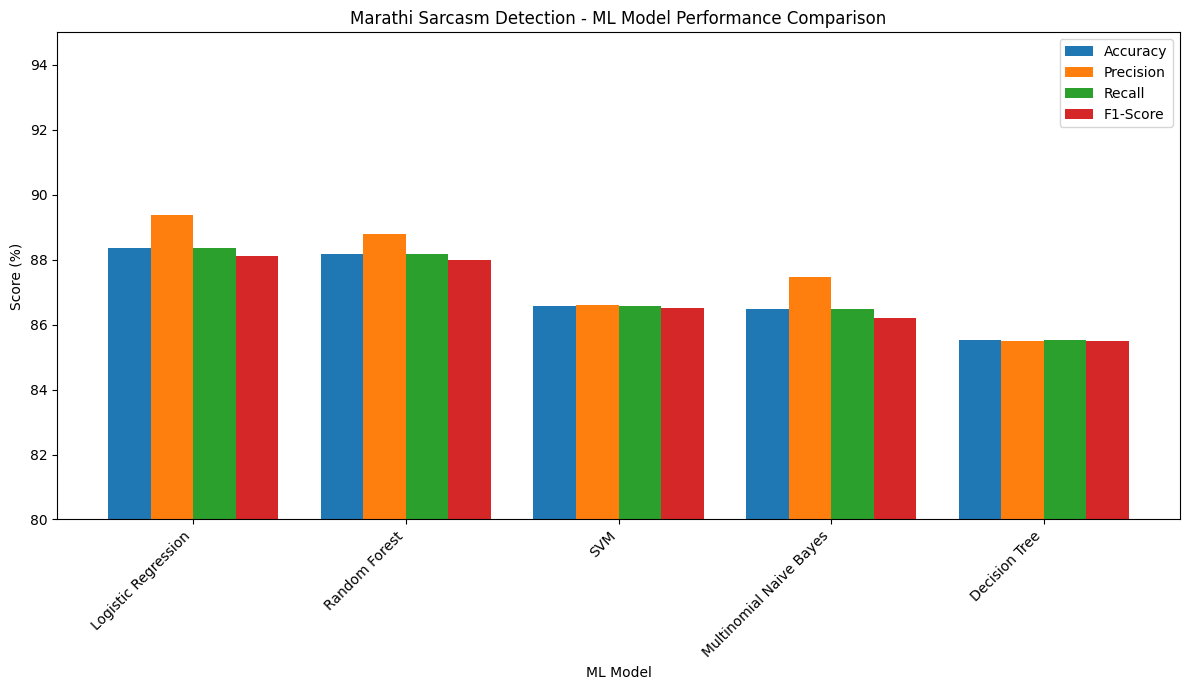

In [68]:
metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]

x = np.arange(len(results_df['Model']))
width = 0.2

plt.figure(figsize=(12, 7))

plt.bar(
    x - 1.5 * width,
    results_df['Accuracy'] * 100,
    width,
    label='Accuracy'
)

plt.bar(
    x - 0.5 * width,
    results_df['Precision'] * 100,
    width,
    label='Precision'
)

plt.bar(
    x + 0.5 * width,
    results_df['Recall'] * 100,
    width,
    label='Recall'
)

plt.bar(
    x + 1.5 * width,
    results_df['F1-Score'] * 100,
    width,
    label='F1-Score'
)

plt.xlabel('ML Model')
plt.ylabel('Score (%)')
plt.title('Marathi Sarcasm Detection - ML Model Performance Comparison')

plt.xticks(
    x,
    results_df['Model'],
    rotation=45,
    ha='right'
)

plt.ylim(80, 95)
plt.legend()

plt.tight_layout()

plt.savefig(
    'sarcasm_ml_all_metrics_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [69]:
from google.colab import files

files.download('sarcasm_ml_accuracy_comparison.png')
files.download('sarcasm_ml_f1_comparison.png')
files.download('sarcasm_ml_all_metrics_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>